# Setup


In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
import time
import os

pd.set_option('display.max_columns', None)

# COMPAS

https://github.com/propublica/compas-analysis/tree/master

COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) is an algorithm used for scoring criminal defendant’s likelihood of reoffending (recidivism). It has been shown that the algorithm is biased in favor of white defendants, and against black inmates.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/provenance/datasets/compas.csv')

In [ ]:
def analyze_df(df):
    display(df.head())
    # display(df.sample(n=5, random_state=42))

    print("\n-- shape --\n")
    print(df.shape)

    print("\n-- data type --\n")
    print(df.dtypes)

    print("\n-- unique values count --\n")
    print(df.nunique())

    print("\n-- NaN values count --\n")
    print(df.isna().sum())

    print("\n-- description --\n")
    print(df.describe())

In [ ]:
analyze_df(df)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0



-- shape --

(7214, 53)

-- data type --

id                           int64
name                        object
first                       object
last                        object
compas_screening_date       object
sex                         object
dob                         object
age                          int64
age_cat                     object
race                        object
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                   object
c_jail_out                  object
c_case_number               object
c_offense_date              object
c_arrest_date               object
c_days_from_compas         float64
c_charge_degree             object
c_charge_desc               object
is_recid                     int64
r_case_number               object
r_charge_degree             object
r_days_from_

In [ ]:
prov = Provenance()

# 1.VR VA

Drop features with more than 10% missing values.

Drop unwanted features.

Process date features.



In [ ]:
# Drop features with more than 10% missing values
missing_ratio = df.isnull().mean()
cols_missing = list(missing_ratio[missing_ratio > 0.1].index)
df1 = df.drop(columns=cols_missing)

# Drop unwanted features
cols_unwanted = [
    "name", "first", "last",
    "c_case_number", "days_b_screening_arrest", "decile_score.1",
    "priors_count.1", "type_of_assessment", "v_type_of_assessment",
    "compas_screening_date", "dob", "screening_date", "v_screening_date",
    'is_recid', 'is_violent_recid', 'event'
    ]
df1.drop(columns=cols_unwanted, inplace=True)

# Process date features
df1["c_jail_in"] = pd.to_datetime(df1["c_jail_in"], errors='coerce')
df1["c_jail_out"] = pd.to_datetime(df1["c_jail_out"], errors='coerce')
df1["c_jail_days"] = (df1["c_jail_out"] - df1["c_jail_in"]).dt.days.astype("Int64")
df1.drop(columns=["c_jail_in", "c_jail_out"], inplace=True)
df1["in_custody"] = pd.to_datetime(df1["in_custody"], errors='coerce')
df1["out_custody"] = pd.to_datetime(df1["out_custody"], errors='coerce')
df1["custody_days"] = (df1["out_custody"] - df1["in_custody"]).dt.days.astype("Int64")
df1.drop(columns=["in_custody", "out_custody"], inplace=True)

df1

,id,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,c_days_from_compas,c_charge_degree,c_charge_desc,score_text,v_decile_score,v_score_text,start,end,two_year_recid,c_jail_days,custody_days
0,1,Male,69,Greater than 45,Other,0,1,0,0,0,1.0,F,Aggravated Assault w/Firearm,Low,1,Low,0,327,0,0,7
1,3,Male,34,25 - 45,African-American,0,3,0,0,0,1.0,F,Felony Battery w/Prior Convict,Low,1,Low,9,159,1,10,10
2,4,Male,24,Less than 25,African-American,0,4,0,1,4,1.0,F,Possession of Cocaine,Low,3,Low,0,63,1,1,0
3,5,Male,23,Less than 25,African-American,0,8,1,0,1,1.0,F,Possession of Cannabis,High,6,Medium,0,1174,0,<NA>,<NA>
4,6,Male,43,25 - 45,Other,0,1,0,0,2,76.0,F,arrest case no charge,Low,1,Low,0,1102,0,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,Male,23,Less than 25,African-American,0,7,0,0,0,1.0,F,Deliver Cannabis,Medium,5,Medium,1,860,0,1,2
7210,10997,Male,23,Less than 25,African-American,0,3,0,0,0,1.0,F,Leaving the Scene of Accident,Low,5,Medium,1,790,0,1,2
7211,10999,Male,57,Greater than 45,Other,0,1,0,0,0,1.0,F,Aggravated Battery / Pregnant,Low,1,Low,0,808,0,1,1
7212,11000,Female,33,25 - 45,African-American,0,2,0,0,3,1.0,M,Battery on Law Enforc Officer,Low,2,Low,0,754,0,1,1


In [ ]:
result1, runtime = prov.capture(df, df1, "id")
prov.explain(df, df1, result1)
# provenance.save_result("VR_VA", result1)

Runtime: 0.2438 seconds
-- D_in --

         id                 name      first         last  \
0         1     miguel hernandez     miguel    hernandez   
1         3          kevon dixon      kevon        dixon   
2         4             ed philo         ed        philo   
3         5          marcu brown      marcu        brown   
4         6   bouthy pierrelouis     bouthy  pierrelouis   
...     ...                  ...        ...          ...   
7209  10996        steven butler     steven       butler   
7210  10997      malcolm simmons    malcolm      simmons   
7211  10999      winston gregory    winston      gregory   
7212  11000          farrah jean     farrah         jean   
7213  11001  florencia sanmartin  florencia    sanmartin   

     compas_screening_date     sex         dob  age          age_cat  \
0               2013-08-14    Male  1947-04-18   69  Greater than 45   
1               2013-01-27    Male  1982-01-22   34          25 - 45   
2               2013-04-14 

# 2.HR

Drop rows with NaN values


In [ ]:
df2 = df1.dropna()
df2.head()

,id,sex,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,c_days_from_compas,c_charge_degree,c_charge_desc,score_text,v_decile_score,v_score_text,start,end,two_year_recid,c_jail_days,custody_days
0,1,Male,69,Greater than 45,Other,0,1,0,0,0,1.0,F,Aggravated Assault w/Firearm,Low,1,Low,0,327,0,0,7
1,3,Male,34,25 - 45,African-American,0,3,0,0,0,1.0,F,Felony Battery w/Prior Convict,Low,1,Low,9,159,1,10,10
2,4,Male,24,Less than 25,African-American,0,4,0,1,4,1.0,F,Possession of Cocaine,Low,3,Low,0,63,1,1,0
5,7,Male,44,25 - 45,Other,0,1,0,0,0,0.0,M,Battery,Low,1,Low,1,853,0,1,1
6,8,Male,41,25 - 45,Caucasian,0,6,0,0,14,1.0,F,Possession Burglary Tools,Medium,2,Low,5,40,1,6,18


In [ ]:
result2, runtime = prov.capture(df1, df2, "id")
prov.explain(df1, df2, result2)
# provenance.save_result("HR", result2)

Runtime: 0.3563 seconds
-- D_in --

         id     sex  age          age_cat              race  juv_fel_count  \
0         1    Male   69  Greater than 45             Other              0   
1         3    Male   34          25 - 45  African-American              0   
2         4    Male   24     Less than 25  African-American              0   
3         5    Male   23     Less than 25  African-American              0   
4         6    Male   43          25 - 45             Other              0   
...     ...     ...  ...              ...               ...            ...   
7209  10996    Male   23     Less than 25  African-American              0   
7210  10997    Male   23     Less than 25  African-American              0   
7211  10999    Male   57  Greater than 45             Other              0   
7212  11000  Female   33          25 - 45  African-American              0   
7213  11001  Female   23     Less than 25          Hispanic              0   

      decile_score  juv_mis

# 3.DT VR VA

Encode categorical columns. Normalize numerical columns.

Select Features






In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import pandas as pd

k_num = 5
k_cat = 20

cols_categorical = [
    'age_cat', 'c_charge_degree',
    'c_charge_desc', 'score_text', 'v_score_text'
]
cols_numerical = [
    'age', 'juv_fel_count', 'decile_score', 'juv_misd_count',
    'juv_other_count', 'priors_count', 'c_days_from_compas',
    'v_decile_score', 'start', 'end', 'c_jail_days', 'custody_days'
]


numerical_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=k_num))
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ('selector', SelectKBest(score_func=chi2, k=k_cat))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, cols_numerical),
    ('cat', categorical_pipeline, cols_categorical)
])

X = df2[cols_numerical + cols_categorical]
y = df2["two_year_recid"]
preprocessor.fit(X, y)
X_processed = preprocessor.transform(X)


cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_feature_names_all = cat_encoder.get_feature_names_out(cols_categorical)

cat_selector = preprocessor.named_transformers_['cat'].named_steps['selector']
num_selector = preprocessor.named_transformers_['num'].named_steps['selector']
cat_selected_names = cat_feature_names_all[cat_selector.get_support()]
num_selected_names = [name for i, name in enumerate(cols_numerical) if num_selector.get_support()[i]]

all_feature_names = num_selected_names + list(cat_selected_names)

df3 = pd.DataFrame(X_processed, columns=all_feature_names)
df3.insert(0, 'id', df2['id'].values)

df3.head()


,id,age,decile_score,priors_count,v_decile_score,end,age_cat_Greater than 45,age_cat_Less than 25,c_charge_degree_F,c_charge_degree_M,c_charge_desc_Battery,c_charge_desc_Burglary Conveyance Unoccup,c_charge_desc_DUI - Enhanced,c_charge_desc_DUI Level 0.15 Or Minor In Veh,c_charge_desc_DUI Property Damage/Injury,c_charge_desc_Driving Under The Influence,c_charge_desc_False Ownership Info/Pawn Item,c_charge_desc_Felony Petit Theft,c_charge_desc_Poss Pyrrolidinovalerophenone,c_charge_desc_Possession of Cocaine,score_text_High,score_text_Low,score_text_Medium,v_score_text_High,v_score_text_Low,v_score_text_Medium
0,1,2.907766,-1.230097,-0.709270,-1.075750,-0.537270,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,3,-0.055461,-0.529274,-0.709270,-1.075750,-0.960714,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,4,-0.902097,-0.178862,0.102164,-0.278599,-1.202682,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,7,0.791175,-1.230097,-0.709270,-1.075750,0.788513,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,8,0.537185,0.521961,2.130749,-0.677174,-1.260653,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


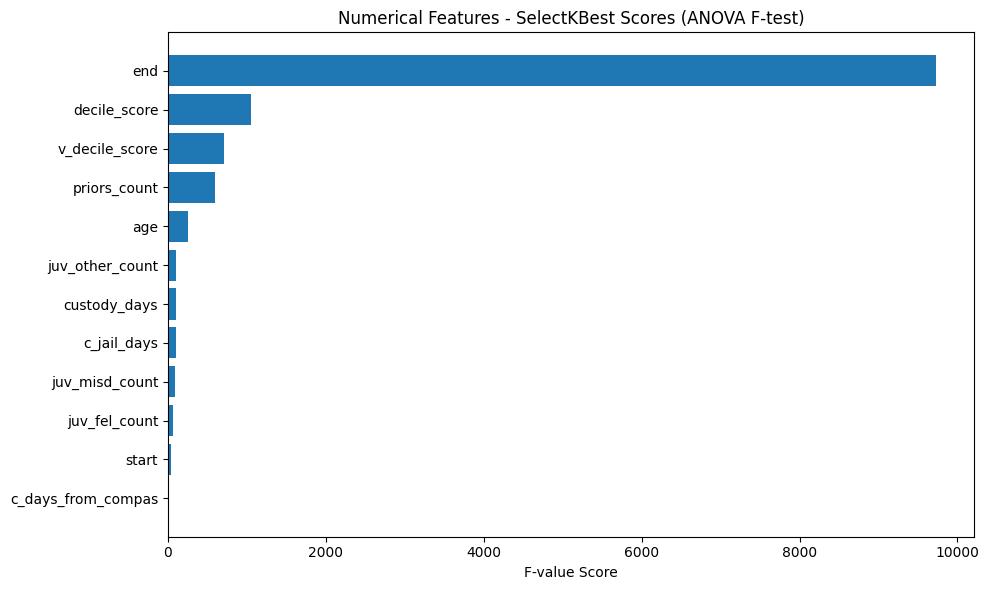

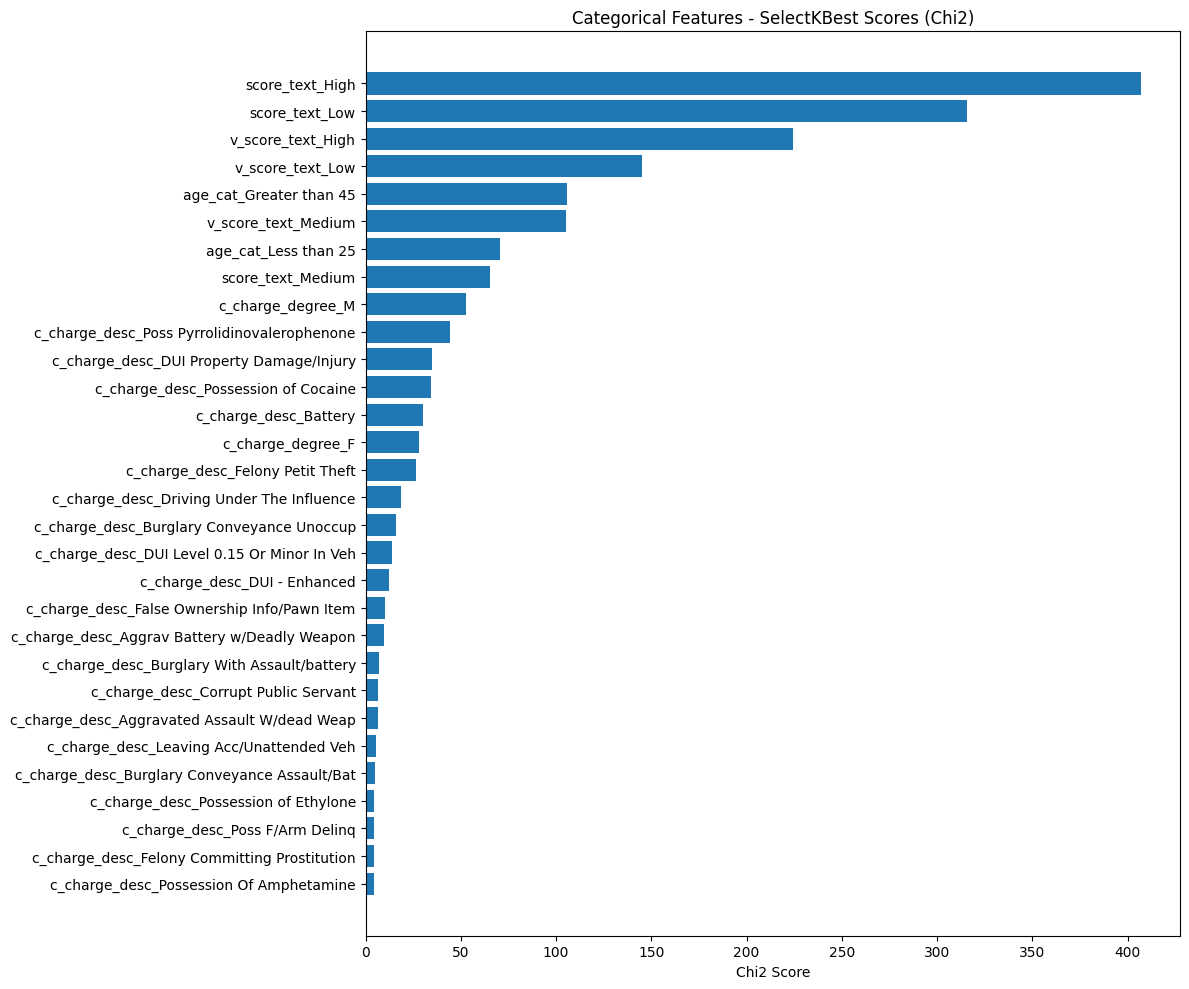

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_scores = num_selector.scores_
num_scores_array = np.array(num_scores)
num_names_array = np.array(cols_numerical)
num_top_indices = np.argsort(num_scores_array)[::-1]
sorted_num_names = num_names_array[num_top_indices]
sorted_num_scores = num_scores_array[num_top_indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_num_names, sorted_num_scores)
plt.xlabel('F-value Score')
plt.title('Numerical Features - SelectKBest Scores (ANOVA F-test)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

cat_scores = cat_selector.scores_
cat_names = cat_encoder.get_feature_names_out(cols_categorical)
cat_scores_array = np.array(cat_scores)
top_k = 30
top_indices = np.argsort(cat_scores_array)[-top_k:][::-1]
top_cat_names = cat_names[top_indices]
top_cat_scores = cat_scores_array[top_indices]

plt.figure(figsize=(12, 10))
plt.barh(top_cat_names, top_cat_scores)
plt.xlabel('Chi2 Score')
plt.title('Categorical Features - SelectKBest Scores (Chi2)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
column_mapping = onehot_column_mapping(df2.columns, df3.columns)
column_mapping

{'c_charge_degree': ['c_charge_degree_F', 'c_charge_degree_M'],
 'c_charge_desc': ['c_charge_desc_Battery',
  'c_charge_desc_Burglary Conveyance Unoccup',
  'c_charge_desc_DUI - Enhanced',
  'c_charge_desc_DUI Level 0.15 Or Minor In Veh',
  'c_charge_desc_DUI Property Damage/Injury',
  'c_charge_desc_Driving Under The Influence',
  'c_charge_desc_False Ownership Info/Pawn Item',
  'c_charge_desc_Felony Petit Theft',
  'c_charge_desc_Poss Pyrrolidinovalerophenone',
  'c_charge_desc_Possession of Cocaine'],
 'v_score_text': ['v_score_text_High',
  'v_score_text_Low',
  'v_score_text_Medium'],
 'score_text': ['score_text_High', 'score_text_Low', 'score_text_Medium'],
 'age_cat': ['age_cat_Greater than 45', 'age_cat_Less than 25']}

In [ ]:
result3, runtime = prov.capture(df2, df3, "id", column_mapping)
prov.explain(df2, df3, result3)
# provenance.save_result("DT_VR_VA", result3)

Runtime: 0.4744 seconds
-- D_in --

         id     sex  age          age_cat              race  juv_fel_count  \
0         1    Male   69  Greater than 45             Other              0   
1         3    Male   34          25 - 45  African-American              0   
2         4    Male   24     Less than 25  African-American              0   
5         7    Male   44          25 - 45             Other              0   
6         8    Male   41          25 - 45         Caucasian              0   
...     ...     ...  ...              ...               ...            ...   
7209  10996    Male   23     Less than 25  African-American              0   
7210  10997    Male   23     Less than 25  African-American              0   
7211  10999    Male   57  Greater than 45             Other              0   
7212  11000  Female   33          25 - 45  African-American              0   
7213  11001  Female   23     Less than 25          Hispanic              0   

      decile_score  juv_mis

# 4.HR
Train-Test split.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df3, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)




X_train.head()

,id,age,decile_score,priors_count,v_decile_score,end,age_cat_Greater than 45,age_cat_Less than 25,c_charge_degree_F,c_charge_degree_M,c_charge_desc_Battery,c_charge_desc_Burglary Conveyance Unoccup,c_charge_desc_DUI - Enhanced,c_charge_desc_DUI Level 0.15 Or Minor In Veh,c_charge_desc_DUI Property Damage/Injury,c_charge_desc_Driving Under The Influence,c_charge_desc_False Ownership Info/Pawn Item,c_charge_desc_Felony Petit Theft,c_charge_desc_Poss Pyrrolidinovalerophenone,c_charge_desc_Possession of Cocaine,score_text_High,score_text_Low,score_text_Medium,v_score_text_High,v_score_text_Low,v_score_text_Medium
1486,2380,-0.563443,0.171549,-0.303553,0.119977,0.760787,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4702,7510,-0.140124,-1.230097,-0.709270,-1.075750,1.310256,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4995,7981,0.198530,0.872373,1.927890,-0.278599,0.707857,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2759,4404,-0.563443,1.923608,-0.709270,0.917128,-0.375958,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5428,8663,-0.732770,-0.178862,-0.506411,0.518553,-1.253092,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
result4, runtime = prov.capture(df3, X_train, "id")
prov.explain(df3, X_train, result4)
# provenance.save_result("HR", result3)

Runtime: 0.2813 seconds
-- D_in --

         id       age  decile_score  priors_count  v_decile_score       end  \
0         1  2.907766     -1.230097     -0.709270       -1.075750 -0.537270   
1         3 -0.055461     -0.529274     -0.709270       -1.075750 -0.960714   
2         4 -0.902097     -0.178862      0.102164       -0.278599 -1.202682   
3         7  0.791175     -1.230097     -0.709270       -1.075750  0.788513   
4         8  0.537185      0.521961      2.130749       -0.677174 -1.260653   
...     ...       ...           ...           ...             ...       ...   
6895  10996 -0.986761      0.872373     -0.709270        0.518553  0.806156   
6896  10997 -0.986761     -0.529274     -0.709270        0.518553  0.629721   
6897  10999  1.891803     -1.230097     -0.709270       -1.075750  0.675090   
6898  11000 -0.140124     -0.879686     -0.100694       -0.677174  0.538983   
6899  11001 -0.986761     -0.178862     -0.303553        0.119977 -0.711185   

      age_cat_G

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.83      0.89       741
           1       0.83      0.96      0.89       639

    accuracy                           0.89      1380
   macro avg       0.90      0.90      0.89      1380
weighted avg       0.90      0.89      0.89      1380

[[617 124]
 [ 23 616]]


# Trace




In [ ]:
df_list = [df, df1, df2, df3, X_train]
result_list = [result1, result2, result3, result4]
tensor_list = [result[0] for result in result_list]
attr_list = [result[1] for result in result_list]

In [ ]:
print(tensor_list[0])

<COOrdinate sparse matrix of dtype 'int8'
	with 7214 stored elements and shape (7214, 7214)>
  Coords	Values
  (0, 0)	1
  (1, 1)	1
  (2, 2)	1
  (3, 3)	1
  (4, 4)	1
  (5, 5)	1
  (6, 6)	1
  (7, 7)	1
  (8, 8)	1
  (9, 9)	1
  (10, 10)	1
  (11, 11)	1
  (12, 12)	1
  (13, 13)	1
  (14, 14)	1
  (15, 15)	1
  (16, 16)	1
  (17, 17)	1
  (18, 18)	1
  (19, 19)	1
  (20, 20)	1
  (21, 21)	1
  (22, 22)	1
  (23, 23)	1
  (24, 24)	1
  :	:
  (7189, 7189)	1
  (7190, 7190)	1
  (7191, 7191)	1
  (7192, 7192)	1
  (7193, 7193)	1
  (7194, 7194)	1
  (7195, 7195)	1
  (7196, 7196)	1
  (7197, 7197)	1
  (7198, 7198)	1
  (7199, 7199)	1
  (7200, 7200)	1
  (7201, 7201)	1
  (7202, 7202)	1
  (7203, 7203)	1
  (7204, 7204)	1
  (7205, 7205)	1
  (7206, 7206)	1
  (7207, 7207)	1
  (7208, 7208)	1
  (7209, 7209)	1
  (7210, 7210)	1
  (7211, 7211)	1
  (7212, 7212)	1
  (7213, 7213)	1


In [ ]:
print("\n-- Records --\n")
trace_record = trace(tensor_list, direction="backward", indices=None, keep_path=False)
print(trace_record)

print("\n-- Records sliced --\n")
trace_record_sliced = trace(tensor_list, direction="backward", indices=[1, 2], keep_path=False)
print(trace_record_sliced)

print("\n-- Records with path --\n")
trace_record_path = trace(tensor_list, direction="backward", indices=None, keep_path=True)
print(trace_record_path)

print("\n-- Records sliced with path --\n")
trace_record_sliced_path = trace(tensor_list, direction="backward", indices=[1, 2], keep_path=True)
print(trace_record_sliced_path)


-- Records --

[[   0 1550]
 [   1 4930]
 [   2 5233]
 ...
 [5517 5612]
 [5518 1806]
 [5519 2731]]

-- Records sliced --

[[   1 4930]
 [   2 5233]]

-- Records with path --

[[   0 1486 1486 1550 1550]
 [   1 4702 4702 4930 4930]
 [   2 4995 4995 5233 5233]
 ...
 [5517 5357 5357 5612 5612]
 [5518 1727 1727 1806 1806]
 [5519 2617 2617 2731 2731]]

-- Records sliced with path --

[[   1 4702 4702 4930 4930]
 [   2 4995 4995 5233 5233]]


# Percentage

In [ ]:
def compute_percentages(df, column):
    percentages = df[column].value_counts(normalize=True)
    return percentages

In [ ]:
print("\n-- df --\n")
display(df.head())
print("\n-- X_train --\n")
display(X_train.head())

print("\n-- df_selected --\n")
indices = trace_record[:, 1]
df_selected = df.iloc[indices]
display(df_selected.head())


-- df --



,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0



-- X_train --



,id,age,decile_score,priors_count,v_decile_score,end,age_cat_Greater than 45,age_cat_Less than 25,c_charge_degree_F,c_charge_degree_M,c_charge_desc_Battery,c_charge_desc_Burglary Conveyance Unoccup,c_charge_desc_DUI - Enhanced,c_charge_desc_DUI Level 0.15 Or Minor In Veh,c_charge_desc_DUI Property Damage/Injury,c_charge_desc_Driving Under The Influence,c_charge_desc_False Ownership Info/Pawn Item,c_charge_desc_Felony Petit Theft,c_charge_desc_Poss Pyrrolidinovalerophenone,c_charge_desc_Possession of Cocaine,score_text_High,score_text_Low,score_text_Medium,v_score_text_High,v_score_text_Low,v_score_text_Medium
1486,2380,-0.563443,0.171549,-0.303553,0.119977,0.760787,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4702,7510,-0.140124,-1.230097,-0.709270,-1.075750,1.310256,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4995,7981,0.198530,0.872373,1.927890,-0.278599,0.707857,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2759,4404,-0.563443,1.923608,-0.709270,0.917128,-0.375958,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5428,8663,-0.732770,-0.178862,-0.506411,0.518553,-1.253092,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



-- df_selected --



,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
1550,2380,lorena aristizabal,lorena,aristizabal,2013-12-11,Female,1987-06-25,28,25 - 45,Hispanic,0,5,0,0,2,-68.0,2013-10-04 02:31:01,2013-10-11 10:49:07,13018003MM10A,NaN,2013-10-07,65.0,M,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,5,Medium,2013-12-11,Risk of Violence,4,Low,2013-12-11,2013-10-04,2013-10-11,2,0,842,0,0
4930,7510,irving emmanuel,irving,emmanuel,2013-05-07,Male,1982-09-18,33,25 - 45,African-American,0,1,0,0,0,-1.0,2013-05-06 11:44:29,2013-05-07 01:25:39,13006548CF10A,2013-05-06,NaN,1.0,F,Pos Cannabis W/Intent Sel/Del,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-05-07,Risk of Violence,1,Low,2013-05-07,2013-05-06,2013-05-07,0,0,1060,0,0
5233,7981,christopher kirby,christopher,kirby,2014-01-01,Male,1979-03-18,37,25 - 45,Caucasian,1,7,6,0,13,-1.0,2013-12-31 04:20:51,2014-01-01 09:05:13,14000024CF10A,2013-12-31,NaN,1.0,F,Neglect Child / No Bodily Harm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,7,Medium,2014-01-01,Risk of Violence,3,Low,2014-01-01,2013-12-31,2014-01-01,13,0,821,0,0
2880,4404,deondra porter,deondra,porter,2014-01-23,Female,1988-01-17,28,25 - 45,African-American,0,10,0,0,0,391.0,2015-02-18 04:23:50,2015-02-25 01:47:30,14000973CF10A,2014-01-22,NaN,1.0,F,Felony Committing Prostitution,1,15002030MM10A,(M1),0.0,2015-02-18,Unlaw Use False Name/Identity,2015-02-18,2015-02-25,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,10,High,2014-01-23,Risk of Violence,6,Medium,2014-01-23,2015-02-18,2015-02-25,0,0,391,1,1
5683,8663,louis simonds,louis,simonds,2013-01-09,Male,1989-09-09,26,25 - 45,Other,0,4,0,0,1,-1.0,2013-01-08 03:24:21,2013-01-10 10:20:25,13000320CF10A,2013-01-08,NaN,1.0,F,Pos Cannabis W/Intent Sel/Del,1,13002676CF10A,(M2),0.0,2013-02-21,Susp Drivers Lic 1st Offense,2013-02-21,2013-03-29,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-01-09,Risk of Violence,5,Medium,2013-01-09,2013-02-21,2013-03-29,1,1,43,1,1


In [ ]:
print("\n-- df_selected --\n")
print(compute_percentages(df_selected, "sex"))
print()
print(compute_percentages(df_selected, "race"))

print("\n-- df --\n")
print(compute_percentages(df, "sex"))
print()
print(compute_percentages(df, "race"))


-- df_selected --

sex
Male      0.80779
Female    0.19221
Name: proportion, dtype: float64

race
African-American    0.511957
Caucasian           0.341304
Hispanic            0.087319
Other               0.052717
Asian               0.004348
Native American     0.002355
Name: proportion, dtype: float64

-- df --

sex
Male      0.806626
Female    0.193374
Name: proportion, dtype: float64

race
African-American    0.512337
Caucasian           0.340172
Hispanic            0.088301
Other               0.052259
Asian               0.004436
Native American     0.002495
Name: proportion, dtype: float64
